In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

print("TensorFlow Version:", tf.__version__)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

TensorFlow Version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [5]:
import numpy as np

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Pixel value range: 0.0 to 1.0


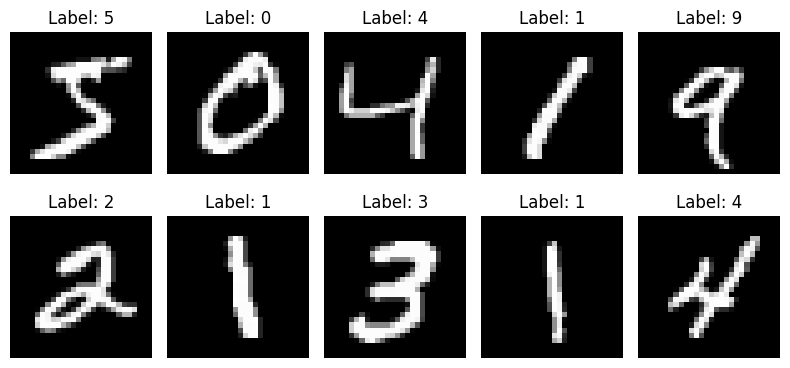

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9354 - loss: 0.2121 - val_accuracy: 0.9827 - val_loss: 0.0549
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9786 - loss: 0.0709 - val_accuracy: 0.9865 - val_loss: 0.0459
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9844 - loss: 0.0495 - val_accuracy: 0.9882 - val_loss: 0.0386
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9877 - loss: 0.0393 - val_accuracy: 0.9890 - val_loss: 0.0385
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9901 - loss: 0.0322 - val_accuracy: 0.9920 - val_loss: 0.0329


In [10]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Loss: 0.0317
Test Accuracy: 98.85 %


In [11]:
predictions = model.predict(x_test[:10], verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

print("Actual Labels:   ", y_test[:10])
print("Predicted Labels:", predicted_labels)

Actual Labels:    [7 2 1 0 4 1 4 9 5 9]
Predicted Labels: [7 2 1 0 4 1 4 9 5 9]


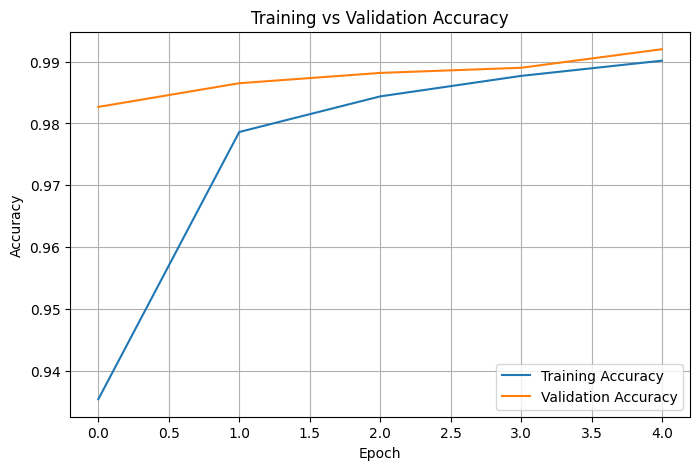

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

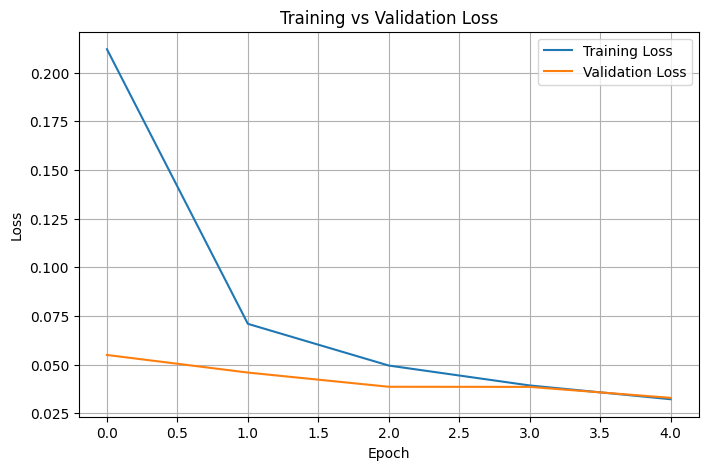

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

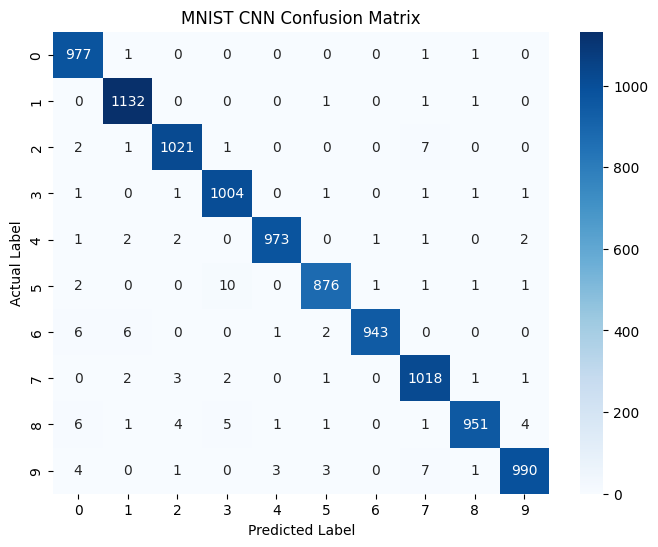

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict all test images
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MNIST CNN Confusion Matrix")

plt.show()

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

ann_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
ann_history = ann_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9124 - loss: 0.3046 - val_accuracy: 0.9662 - val_loss: 0.1236
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9620 - loss: 0.1256 - val_accuracy: 0.9702 - val_loss: 0.1016
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9739 - loss: 0.0863 - val_accuracy: 0.9748 - val_loss: 0.0895
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9797 - loss: 0.0664 - val_accuracy: 0.9777 - val_loss: 0.0770
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9841 - loss: 0.0519 - val_accuracy: 0.9777 - val_loss: 0.0783


In [17]:
ann_loss, ann_accuracy = ann_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("ANN Test Loss:", round(ann_loss, 4))
print("ANN Test Accuracy:", round(ann_accuracy * 100, 2), "%")

ANN Test Loss: 0.0811
ANN Test Accuracy: 97.54 %


In [18]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy (%)": [
        round(ann_accuracy * 100, 2),
        round(test_accuracy * 100, 2)
    ],
    "Test Loss": [
        round(ann_loss, 4),
        round(test_loss, 4)
    ]
})

comparison

,Model,Test Accuracy (%),Test Loss
0,ANN,97.54,0.0811
1,CNN,98.85,0.0317


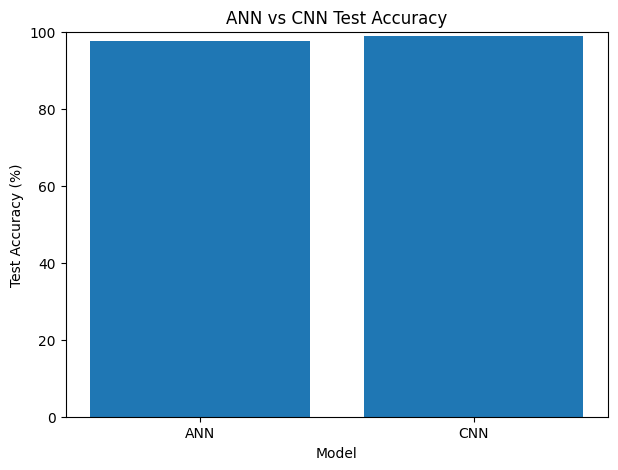

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("ANN vs CNN Test Accuracy")

plt.ylim(0, 100)
plt.show()

Conclusion:
The ANN and CNN models were implemented for MNIST digit classification using TensorFlow/Keras. Both models achieved good classification performance. The CNN generally performs better for image classification because convolutional layers can learn spatial features from images. Therefore, CNN is more suitable for image-based classification tasks
